In [8]:
import notebook_setup
import matplotlib.pyplot as plt
import numpy as np
import json

from src.plot_style import set_plot_style

set_plot_style()

C:\Users\maria\AppData\Local\Temp\ipykernel_18916\785473789.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


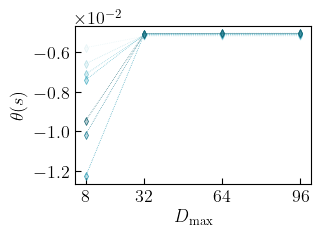

In [ ]:
def cm_to_inch(cm):
    return cm / 2.54

panel_width_cm = 6.0
panel_height_cm = 4.0
margin_cm = 2.0

fig_width = cm_to_inch(panel_width_cm + 2 * margin_cm)
fig_height = cm_to_inch(panel_height_cm + 2 * margin_cm)

fig = plt.figure(figsize=(fig_width, fig_height))

left = margin_cm / (panel_width_cm + 2 * margin_cm)
bottom = margin_cm / (panel_height_cm + 2 * margin_cm)
width = panel_width_cm / (panel_width_cm + 2 * margin_cm)
height = panel_height_cm / (panel_height_cm + 2 * margin_cm)

ax = fig.add_axes([left, bottom, width, height])
num_sites_range = [4, 6, 8, 10, 20, 40, 60]
max_bond_dim_range = [8, 32, 64, 96]
gradient_teal_1 = ["#E4F3F6","#B8E0E7","#82C9D6","#4FB2C6","#2C9CB5","#1F7F95","#166370"]
gradient_teal_03 = [(228/255, 243/255, 246/255, 0.3),(184/255, 224/255, 231/255, 0.3),(130/255, 201/255, 214/255, 0.3),(79/255, 178/255, 198/255, 0.3),(44/255, 156/255, 181/255, 0.3),(31/255, 127/255, 149/255, 0.3),(22/255, 99/255, 112/255, 0.3)]
gradient_orange_1 = ["#FBE9E3","#F6CFC3","#F0B2A0","#EA937D","#E37259","#C85D47","#9F4736"]
gradient_orange_03 = [(251/255, 233/255, 227/255, 0.3),(246/255, 207/255, 195/255, 0.3),(240/255, 178/255, 160/255, 0.3),(234/255, 147/255, 125/255, 0.3),(227/255, 114/255, 89/255, 0.3),(200/255, 93/255, 71/255, 0.3),(159/255, 71/255, 54/255, 0.3),]

with open('data/convergence_data.json', 'r') as f:
    convergence_data = json.load(f)

V_values = [2.000]
s = 0.01
for i, V in enumerate(V_values):
    if V == 2:
        colors = gradient_teal_03
        darker_colors = gradient_teal_1
    else:
        colors = gradient_orange_03
        darker_colors = gradient_orange_1
    for n, num_sites in enumerate(num_sites_range):
        values = convergence_data[f"s_{s:.3f}"][f"V_{V:.3f}"][f"L_{num_sites}"]["theta"]
        marker = 'o' if V == 5.875 else 'd'
        plt.plot(max_bond_dim_range, values, marker=marker, markersize=4.0, 
                markerfacecolor=colors[n], label=f"L={num_sites}" if i == 0 else "",
        markeredgecolor=darker_colors[n], markeredgewidth=0.5, lw=0.5, ls=':', color=darker_colors[n])

ax.set_xlabel(r"$D_\mathrm{max}$", fontsize=13)
ax.set_ylabel(r"$\theta(s)$", fontsize=13)
ax.set_xticks([8, 32, 64, 96])
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
from matplotlib.ticker import ScalarFormatter
sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((0,0))
ax.yaxis.set_major_formatter(sf)
ax.tick_params(axis='y', labelsize=13)  # números
ax.yaxis.offsetText.set_fontsize(13)    # el "×10³"


plt.tight_layout()
plt.savefig(f'figures/svg/figs2_f.svg', bbox_inches='tight', dpi=300, transparent=True)
plt.savefig(f'figures/pdf/figs2_f
            .pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()